# Gas price feature (TTF)

Adds the gas price to the lakehouse. In many hours a gas plant sets the German day-ahead price,
so the gas price explains much of the price **level** that the current features cannot follow.

| Series | Source | Unit | API key |
|---|---|---|---|
| TTF gas, front-month future (`TTF=F`) | Yahoo Finance via `yfinance` | EUR/MWh (thermal) | none |

**Cells:**

1. download the raw data and save it to `data/lakehouse/fuel_prices/raw/`
2. validate it (coverage, gaps, plausible range, jumps)
3. align it point-in-time to delivery days and join it to the hourly master dataset

**Point-in-time rule.** Bids for delivery day **T** are submitted before 12:00 CET on **T−1**.
At that moment today's gas settlement is not known yet.
So delivery day T uses the last closing price **dated T−2 or earlier**, which avoids leakage.

Run from the project root: `pip install yfinance matplotlib` once.


In [1]:
# ---- setup ---------------------------------------------------------------
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from config import LAKEHOUSE_ROOT, MARKET_TZ

FUEL_DIR = LAKEHOUSE_ROOT / "fuel_prices"
RAW_DIR = FUEL_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

START = "2022-12-01"            # one month before the price history starts, so the first delivery days get a value
TTF_TICKER = "TTF=F"            # ICE Endex Dutch TTF front-month future, EUR/MWh



## 1 · Download

Daily closing price of the continuous front-month TTF future from Yahoo Finance.
A continuous series jumps when one monthly contract rolls into the next, so cell 2 flags large jumps for you to look at.


In [2]:
# ---- 1. DOWNLOAD ---------------------------------------------------------

def download_ttf(start: str) -> pd.DataFrame:
    end = (pd.Timestamp.today() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    raw = yf.download(TTF_TICKER, start=start, end=end, interval="1d",
                      auto_adjust=False, progress=False)
    if raw is None or raw.empty:
        raise RuntimeError(f"Yahoo returned no data for {TTF_TICKER}. Check your internet / try again later.")
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):          # newer yfinance: one column per ticker
        close = close.iloc[:, 0]
    idx = pd.to_datetime(close.index)
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    return (pd.DataFrame({"date": idx.normalize().astype("datetime64[ns]"), "ttf_eur_mwh": close.to_numpy(dtype=float)})
            .dropna().sort_values("date").reset_index(drop=True))


print("Downloading TTF gas from Yahoo Finance...")
ttf_raw = download_ttf(START)
print(f"  {len(ttf_raw)} daily rows, {ttf_raw.date.min().date()} -> {ttf_raw.date.max().date()}")


ttf_raw.to_parquet(RAW_DIR / "ttf_yahoo_daily.parquet", index=False)
print(f"Saved -> {RAW_DIR / 'ttf_yahoo_daily.parquet'}")


  959 daily rows, 2022-12-01 -> 2026-09-25
Saved -> data\lakehouse\fuel_prices\raw\ttf_yahoo_daily.parquet


## 2 · Validate

**Hard checks** raise an error, because the data must not be used if they fail:
* history starts early enough
* the last value is recent (no more than 7 days old)
* no duplicate dates
* every value is in a plausible range (5–350 EUR/MWh)

**Soft checks** print a warning, for you to look at:
* gaps longer than 5 calendar days (holidays are normal, e.g. Christmas)
* day-to-day jumps above 25% (for TTF, usually a contract roll or a real market shock)


TTF gas [EUR/MWh]: 959 rows | 2022-12-01 -> 2026-09-25 | min 22.93  median 37.01  max 149.24

2 warning(s):
  - TTF gas [EUR/MWh]: 28% move on 2023-08-09 (value 39.82)
  - TTF gas [EUR/MWh]: 39% move on 2026-03-02 (value 44.51)


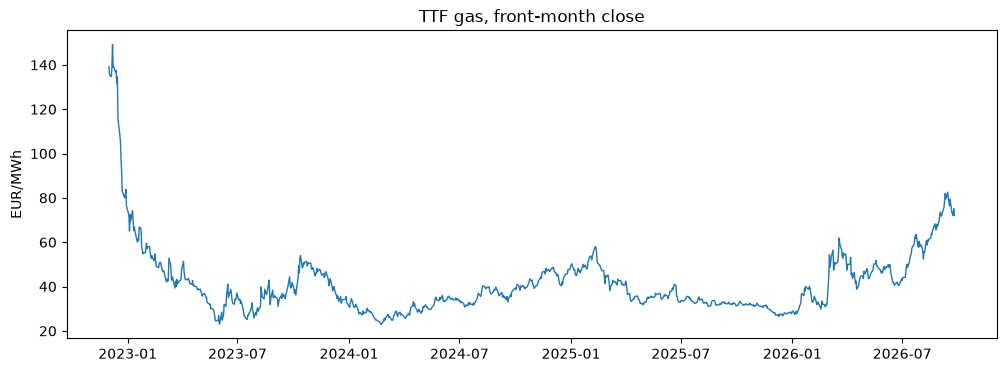


Validation passed.


In [3]:
# ---- 2. VALIDATE ---------------------------------------------------------
ttf_raw = pd.read_parquet(RAW_DIR / "ttf_yahoo_daily.parquet")

def validate(df, col, name, lo, hi, start_by="2022-12-31", max_age_days=7, max_gap_days=5, max_jump=0.25):
    errors, warnings = [], []
    d = df.sort_values("date")

    if d.empty:
        return [f"{name}: no rows"], []
    if d["date"].min() > pd.Timestamp(start_by):
        errors.append(f"{name}: starts {d.date.min().date()}, needs data by {start_by}")
    age = (pd.Timestamp.today().normalize() - d["date"].max()).days
    if age > max_age_days:
        errors.append(f"{name}: last value is {age} days old ({d.date.max().date()})")
    n_dup = d["date"].duplicated().sum()
    if n_dup:
        errors.append(f"{name}: {n_dup} duplicate dates")
    n_nan = d[col].isna().sum()
    if n_nan:
        errors.append(f"{name}: {n_nan} missing values")
    bad = d[(d[col] < lo) | (d[col] > hi)]
    if len(bad):
        errors.append(f"{name}: {len(bad)} values outside [{lo}, {hi}], e.g.\n{bad.head().to_string(index=False)}")

    gaps = d["date"].diff().dt.days
    big_gaps = d.loc[gaps > max_gap_days, "date"]
    for end in big_gaps:
        warnings.append(f"{name}: gap of {int(gaps[d.date == end].iloc[0])} days ending {end.date()}")
    jumps = d[col].pct_change().abs()
    for _, r in d[jumps > max_jump].iterrows():
        warnings.append(f"{name}: {jumps[_]:.0%} move on {r.date.date()} (value {r[col]:.2f})")

    print(f"{name}: {len(d)} rows | {d.date.min().date()} -> {d.date.max().date()} | "
          f"min {d[col].min():.2f}  median {d[col].median():.2f}  max {d[col].max():.2f}")
    return errors, warnings


all_errors, all_warnings = validate(ttf_raw, "ttf_eur_mwh", "TTF gas [EUR/MWh]", 5, 350)

print(f"\n{len(all_warnings)} warning(s):")
for w in all_warnings:
    print("  -", w)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ttf_raw.date, ttf_raw.ttf_eur_mwh, lw=1)
ax.set_ylabel("EUR/MWh"); ax.set_title("TTF gas, front-month close"); plt.show()

if all_errors:
    raise ValueError("Validation FAILED:\n  - " + "\n  - ".join(all_errors))
print("\nValidation passed.")


## 3 · Align with the existing dataset

1. **Daily table per delivery day T.** Take the last TTF close dated **T−2 or earlier** (the point-in-time rule above), using `merge_asof` backward.
   Record how old the value is. On Mondays it is Friday's close, for example.
2. **Hourly join.** Every hour in the master dataset gets the value of its **local (Berlin) delivery date**.
3. **Checks:**
   * no value is dated after T−2 (leakage test)
   * no missing values over the history
   * the plot of daily mean power price vs. TTF looks sensible

Output: `data/lakehouse/fuel_prices/fuel_daily_asof.parquet`, the table the model pipeline will join later.


Age of the value used (days before delivery):
     ttf_age_days
min           2.0
50%           2.0
max           6.0

Saved 1366 delivery days -> data\lakehouse\fuel_prices\fuel_daily_asof.parquet
Found 143 parquet files in 'day_ahead_prices'. Reading and merging...
Found 135 parquet files in 'total_load'. Reading and merging...
Found 108 parquet files in 'generation'. Reading and merging...

--- Dataset: day_ahead_prices ---
Shape: (32759, 3)
Columns: ['timestamp', 'price_eur_mwh', 'bidding_zone']

--- Dataset: total_load ---
Shape: (32735, 5)
Columns: ['timestamp', 'load_mw', 'bidding_zone', 'total_load_mw', 'total_load']

--- Dataset: generation ---
Shape: (32735, 27)
Columns: ['timestamp', 'solar_mw', 'wind_onshore_mw', 'wind_offshore_mw', 'gas_mw', 'hard_coal_mw', 'nuclear_mw', 'bidding_zone', 'Biomass_Actual Aggregated', 'Fossil Brown coal/Lignite_Actual Aggregated', 'Fossil Coal-derived gas_Actual Aggregated', 'Fossil Oil_Actual Aggregated', 'Geothermal_Actual Aggregated', 'Hyd

,timestamp,delivery_date,price_eur_mwh,ttf_eur_mwh
32754,2026-09-26 17:00:00+00:00,2026-09-26,236.7875,75.106003
32755,2026-09-26 18:00:00+00:00,2026-09-26,226.3600,75.106003
32756,2026-09-26 19:00:00+00:00,2026-09-26,208.4875,75.106003
32757,2026-09-26 20:00:00+00:00,2026-09-26,199.3100,75.106003
32758,2026-09-26 21:00:00+00:00,2026-09-26,186.0000,75.106003


Correlation daily mean power price vs TTF: 0.41  (expect clearly positive)


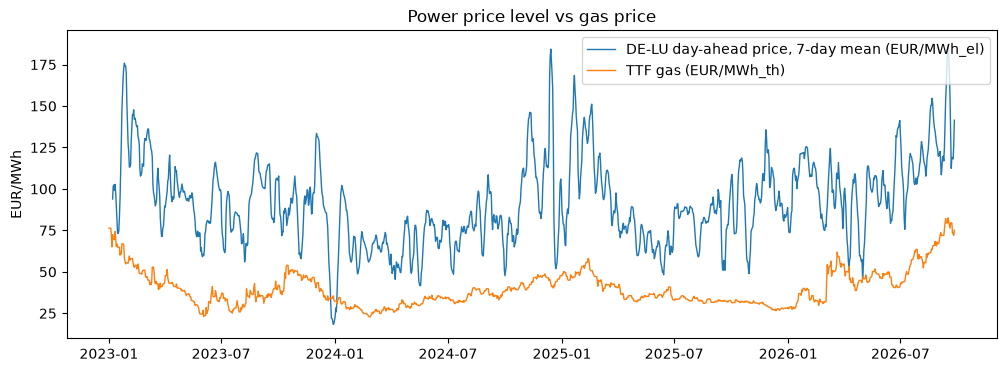

In [4]:
# ---- 3. ALIGN WITH master_energy_df --------------------------------------
from data.historical_loader import load_all_historical, clean_and_merge_data
from data.market_time import local_date

AVAILABLE_LAG_DAYS = 2  # delivery day T uses values dated <= T-2 (gate closure is 12:00 on T-1)

ttf = pd.read_parquet(RAW_DIR / "ttf_yahoo_daily.parquet").rename(columns={"date": "ttf_obs_date"})
# parquet can come back as datetime64[ms]; merge_asof needs identical dtypes on both sides
ttf["ttf_obs_date"] = ttf["ttf_obs_date"].astype("datetime64[ns]")

today_local = pd.Timestamp.now(tz=MARKET_TZ).tz_localize(None).normalize()
days = pd.DataFrame({"delivery_date": pd.date_range("2023-01-01", today_local + pd.Timedelta(days=1), freq="D")})
days["delivery_date"] = days["delivery_date"].astype("datetime64[ns]")
days["asof_date"] = days["delivery_date"] - pd.Timedelta(days=AVAILABLE_LAG_DAYS)

aligned = pd.merge_asof(days.sort_values("asof_date"), ttf.sort_values("ttf_obs_date"),
                        left_on="asof_date", right_on="ttf_obs_date", direction="backward")
aligned["ttf_age_days"] = (aligned.delivery_date - aligned.ttf_obs_date).dt.days

# -- leakage + completeness checks --
assert (aligned.ttf_obs_date <= aligned.asof_date).all(), "TTF value from after T-2 used!"
missing = aligned["ttf_eur_mwh"].isna().sum()
assert missing == 0, f"{missing} delivery days without a TTF value"
print("Age of the value used (days before delivery):")
print(aligned[["ttf_age_days"]].describe().loc[["min", "50%", "max"]].round(1).to_string())
stale = aligned[aligned.ttf_age_days > 7]
if len(stale):
    print(f"WARNING: {len(stale)} delivery days use a value older than 7 days, e.g. {stale.delivery_date.dt.date.head(3).tolist()}")

aligned.to_parquet(FUEL_DIR / "fuel_daily_asof.parquet", index=False)
print(f"\nSaved {len(aligned)} delivery days -> {FUEL_DIR / 'fuel_daily_asof.parquet'}")

# -- join to the hourly master dataset --
master = clean_and_merge_data(load_all_historical())
master["delivery_date"] = pd.to_datetime(local_date(master["timestamp"])).astype("datetime64[ns]")
fuel_cols = ["ttf_eur_mwh"]
master_fuel = master.merge(aligned[["delivery_date"] + fuel_cols], on="delivery_date", how="left")

assert len(master_fuel) == len(master), "join changed the number of rows"
print(f"\nmaster rows: {len(master_fuel)}, rows without fuel data: {master_fuel[fuel_cols].isna().any(axis=1).sum()}")
display(master_fuel[["timestamp", "delivery_date", "price_eur_mwh"] + fuel_cols].tail(5))

# -- sanity check: does the power price level follow gas? --
daily = master_fuel.groupby("delivery_date").agg(price=("price_eur_mwh", "mean"), ttf=("ttf_eur_mwh", "first"))
print(f"Correlation daily mean power price vs TTF: {daily.price.corr(daily.ttf):.2f}  (expect clearly positive)")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.price.rolling(7).mean(), lw=1, label="DE-LU day-ahead price, 7-day mean (EUR/MWh_el)")
ax.plot(daily.index, daily.ttf, lw=1, label="TTF gas (EUR/MWh_th)")
ax.set_ylabel("EUR/MWh"); ax.legend(); ax.set_title("Power price level vs gas price"); plt.show()
